In [2]:
# importing libraries

import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

#loading data
dataset=load_dataset('lukebarousse/data_jobs')
df=dataset['train'].to_pandas()

#data cleanup $ convert job skills column from a string to a list
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])
df['job_skills']=df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x) else x)

#Filter for Data Analyst data
df_DA =df[df['job_title_short']=='Data Analyst'].copy()

### Customizing my line chart

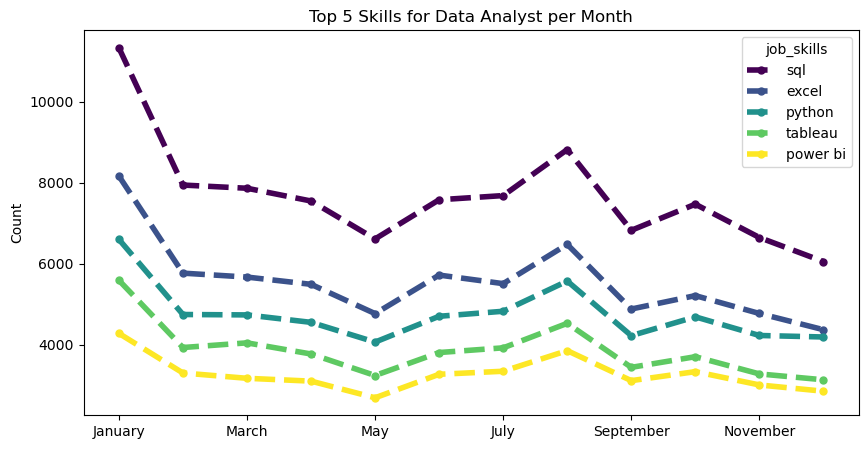

In [20]:
# Create a new column for months from job poated date column
df_DA['job_posted_month_no']=df_DA['job_posted_date'].dt.month

# To extract skills for job_skills column we use explode
df_DA_explode = df_DA.explode('job_skills')

# Lets pivot the table
# we use fill value to remove blanks and addvalue taht we want
df_DA_pivot=df_DA_explode.pivot_table(index='job_posted_month_no', columns='job_skills', aggfunc='size', fill_value=0)

#Lets create a new raw called total
df_DA_pivot.loc['Total']=df_DA_pivot.sum()

#Lets sort total raw column and make it alist by adding index
df_DA_pivot.loc['Total'].sort_values(ascending=False).index

# lets sort all values in hhe pivot by previous code
Sort_columns =df_DA_pivot.loc['Total'].sort_values(ascending=False).index
df_DA_pivot=df_DA_pivot[Sort_columns]

#lets total raw
df_DA_pivot=df_DA_pivot.drop('Total')

import calendar

# convert month numbers → month names
df_DA_pivot.index = df_DA_pivot.index.map(lambda x: calendar.month_name[x])

#lets plot the first 5 columns
df_DA_pivot.iloc[:, :5].plot(
  kind='line',
  linewidth=4,
  linestyle='--',# to get dash lines
  colormap='viridis',
  marker='o',  #options: 'o','x','+','*','s','1'
  markersize=5,
  figsize=(10,5)
)
plt.title('Top 5 Skills for Data Analyst per Month')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

## Customizing our Scatter plot from **15_Scatter_Plot.ipynb**

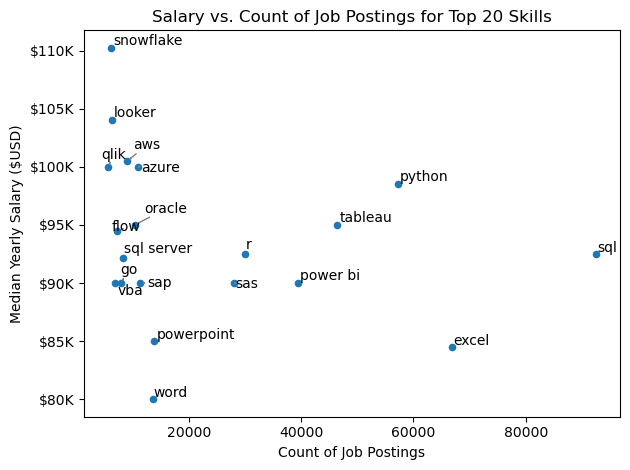

In [39]:
from adjustText import adjust_text
df=df[df['job_title_short']=='Data Analyst']
df_exploded=df.explode('job_skills') # exploding the job skills column in order to extract skills
skill_stats=df_exploded.groupby('job_skills').agg(
  skill_count=('job_skills', 'count'),
  median_salary=('salary_year_avg', 'median')
)

#Limit to the top skills
skill_count=20
skills_stat =skill_stats.sort_values(by='skill_count', ascending=False).head(skill_count)


#Lets plot
skills_stat.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Postings for Top 20 Skills')
plt.tight_layout()

texts=[]
for i, txt in enumerate(skills_stat.index):
 texts.append( plt.text(skills_stat['skill_count'].iloc[i], skills_stat['median_salary'].iloc[i], txt))

adjust_text(texts, arrowprops=dict(arrowstyle="->", color='grey', lw=1))
#customixe Y axis
ax=plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, pos: f'${int(y/1000)}K'))

#adjust layout and display plot
plt.tight_layout()
plt.show()